# Imports

In [1]:
!pip install keras_cv
!pip install -q -U keras-tuner

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 122.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 140.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.6/167.6 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.9/152.9 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.5/294.5 kB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 22.6 MB/s eta 

In [10]:


from keras.utils import image_dataset_from_directory
import os
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from keras.applications import EfficientNetV2M

from keras.layers import GlobalAveragePooling2D, Dense, Dropout

from keras import Input, Model

from keras.optimizers import RMSprop

from keras.losses import CategoricalCrossentropy

from keras.metrics import CategoricalAccuracy, AUC, F1Score

from keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler

from keras.optimizers.schedules import CosineDecayRestarts
from tensorflow import keras

import keras

import keras_cv
import keras_tuner as kt



Using TensorFlow backend


In [13]:
print(f"Keras version: {keras.__version__}")
print(f"Keras Tuner: {kt.__version__}")
print(f"KerasCV version: {keras_cv.__version__}")

Keras version: 2.15.0
Keras Tuner: 1.4.7
KerasCV version: 0.9.0


In [ ]:
import sys
sys.path.append('..')

from utils_ import (
    load_images,
    load_tabular_features,
    reorder_dataframe,
    merge_tabular_with_images,
    build_model,
    LearningRateLogger,
    InlineLogger, 
    compile_model,
    train_model,
    evaluate_model, 
    store_results, 
    plot_results,
    plot_training_curves,
    unfreeze_model_layers,
    get_best_epoch, 
)
from utils_ import *

# Defining hyperparameters

In [15]:
IMAGE_SIZE = (224,224)
IMAGE_SHAPE = (IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
BATCH_SIZE = 64
EPOCHS = 100

In [16]:
metrics = [
    keras.metrics.F1Score(average="macro", name="f1_score"),
    keras.metrics.F1Score(average="weighted", name="f1_score_weighted")
    ]

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint("checkpoint.keras", monitor="val_loss", verbose=0),
    keras.callbacks.CSVLogger("metrics.csv"),
    keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5, restore_best_weights=True),
    InlineLogger()
]

# Funcoes

# Images loading into tensor

In [ ]:
train_ds, val_ds, test_ds, class_names = load_images(
    folder_name="../data", 
    batch_size=BATCH_SIZE, 
    image_size=IMAGE_SIZE, 
    interpolation="bilinear",
    shuffle=False,
    random_seed=42)


Found 8367 files belonging to 202 classes.
Found 1723 files belonging to 202 classes.


2025-04-29 17:48:16.830825: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-29 17:48:16.947137: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-29 17:48:16.947327: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Found 1893 files belonging to 202 classes.


In [10]:
class_names

['arthropoda_apidae',
 'arthropoda_attelabidae',
 'arthropoda_carabidae',
 'arthropoda_cerambycidae',
 'arthropoda_coenagrionidae',
 'arthropoda_formicidae',
 'arthropoda_gomphidae',
 'arthropoda_lucanidae',
 'arthropoda_nymphalidae',
 'arthropoda_palinuridae',
 'arthropoda_papilionidae',
 'arthropoda_pisauridae',
 'arthropoda_platystictidae',
 'arthropoda_pseudophasmatidae',
 'arthropoda_tettigoniidae',
 'arthropoda_theraphosidae',
 'arthropoda_triopsidae',
 'chordata_accipitridae',
 'chordata_acipenseridae',
 'chordata_agamidae',
 'chordata_albulidae',
 'chordata_alcedinidae',
 'chordata_alligatoridae',
 'chordata_alopiidae',
 'chordata_ambystomatidae',
 'chordata_anatidae',
 'chordata_anguidae',
 'chordata_aotidae',
 'chordata_ardeidae',
 'chordata_arthroleptidae',
 'chordata_atelidae',
 'chordata_balaenicipitidae',
 'chordata_balaenidae',
 'chordata_balaenopteridae',
 'chordata_balistidae',
 'chordata_bombycillidae',
 'chordata_bovidae',
 'chordata_brachypteraciidae',
 'chordata_bu

# Loading tabular features and merging

In [ ]:
df_train = pd.read_csv("../data/metadata_train.csv")
df_val = pd.read_csv("../data/metadata_val.csv")
df_test = pd.read_csv("../data/metadata_test.csv")

In [ ]:
df_train_reordered = reorder_dataframe(df_train, "../data/train")
df_val_reordered = reorder_dataframe(df_val, "../data/val")
df_test_reordered = reorder_dataframe(df_test, "../data/test")

> The reorder_dataframe function is used to reorder the DataFrame based on the file paths of images in a specified folder. <br>
This way it will align the tabular data (phylum) with the images in the dataset for merging into a combined tensorflow dataset.

In [13]:
df_val_reordered

,file_path,rare_species_id,eol_content_id,eol_page_id,kingdom,phylum,family
0,arthropoda_apidae/21834167_1065290_eol-full-si...,451a5f50-9fba-4640-8710-4596887d392d,21834167,1065290,animalia,arthropoda,apidae
1,arthropoda_apidae/21847572_1065348_eol-full-si...,016cf26d-4a25-435f-b1d2-220edd8857df,21847572,1065348,animalia,arthropoda,apidae
2,arthropoda_apidae/21847574_1065348_eol-full-si...,ff835401-7584-45f1-a65d-1e0a60e4a292,21847574,1065348,animalia,arthropoda,apidae
3,arthropoda_apidae/21847575_1065348_eol-full-si...,b4229df2-0e95-4009-a886-471c4e294905,21847575,1065348,animalia,arthropoda,apidae
4,arthropoda_apidae/22375122_1065346_eol-full-si...,8618adb7-2193-4834-91a4-06e39cfcaa56,22375122,1065346,animalia,arthropoda,apidae
...,...,...,...,...,...,...,...
1718,mollusca_unionidae/2744864_449459_eol-full-siz...,8cda80d3-43ad-48fb-b5fd-91f739dfa428,2744864,449459,animalia,mollusca,unionidae
1719,mollusca_zonitidae/20925364_4890709_eol-full-s...,d768514c-ab22-4f70-a02e-937965441e9d,20925364,4890709,animalia,mollusca,zonitidae
1720,mollusca_zonitidae/29423017_4890709_eol-full-s...,54f9a1b9-418d-4a7b-a444-9c32591c06f0,29423017,4890709,animalia,mollusca,zonitidae
1721,mollusca_zonitidae/29423021_4890709_eol-full-s...,ff7e3f1d-799a-4018-99f8-bfa9c553caec,29423021,4890709,animalia,mollusca,zonitidae


In [14]:
phylum_columns = pd.get_dummies(df_train_reordered["phylum"]).columns.tolist()

train_tabular = pd.get_dummies(df_train_reordered["phylum"])[phylum_columns].to_numpy()
val_tabular = pd.get_dummies(df_val_reordered["phylum"])[phylum_columns].to_numpy()
test_tabular = pd.get_dummies(df_test_reordered["phylum"])[phylum_columns].to_numpy()

In [15]:
phylum_columns

['arthropoda', 'chordata', 'cnidaria', 'echinodermata', 'mollusca']

In [16]:
print(train_tabular.shape, val_tabular.shape, test_tabular.shape)


(8367, 5) (1723, 5) (1893, 5)


In [17]:
train_ds = merge_tabular_with_images(train_ds, train_tabular, BATCH_SIZE, shuffle=True, shuffle_buffer=1000)
val_ds = merge_tabular_with_images(val_ds, val_tabular, BATCH_SIZE)
test_ds = merge_tabular_with_images(test_ds, test_tabular, BATCH_SIZE)

In [18]:
train_ds

<_PrefetchDataset element_spec=({'image_input': TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), 'tabular_input': TensorSpec(shape=(None, 5), dtype=tf.bool, name=None)}, TensorSpec(shape=(None, 202), dtype=tf.float32, name=None))>

In [19]:
elem_spec = train_ds.element_spec
for key, tensor_spec in elem_spec[0].items():
    print(f"{key}: shape={tensor_spec.shape}, dtype={tensor_spec.dtype}")

image_input: shape=(None, 224, 224, 3), dtype=<dtype: 'float32'>
tabular_input: shape=(None, 5), dtype=<dtype: 'bool'>


In [20]:
for elem in train_ds.take(1):
    print("Image shape:", elem[0]["image_input"].shape)
    print("Tabular shape:", elem[0]["tabular_input"].shape)
    print("Label shape:", elem[1].shape)

Image shape: (64, 224, 224, 3)
Tabular shape: (64, 5)
Label shape: (64, 202)


2025-04-29 17:48:28.392891: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-04-29 17:48:28.451417: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [21]:
import numpy as np

for batch in val_ds.take(1):
    inputs, labels = batch
    images = inputs["image_input"]
    tabular = inputs["tabular_input"]

    tabular_row = tabular[0].numpy()
    tabular_index = np.argmax(tabular_row)
    
    label = labels[0].numpy()

    label_index = np.argmax(label)
    label_name = class_names[label_index]

    print("Tabular data:", tabular_row)
    print("Phylum:", phylum_columns[tabular_index])
    print("Label index:", label_index)
    print("Label name:", label_name)

Tabular data: [ True False False False False]
Phylum: arthropoda
Label index: 0
Label name: arthropoda_apidae


2025-04-29 17:48:29.169855: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-04-29 17:48:29.169995: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


# Feature selection

In [23]:
use_tabular = [False, True]
tabular_projection = [True, False]


In [24]:
train_results = []
validation_results = []

for case in use_tabular:
    for projection in tabular_projection:
        if case == False and projection == True:
            continue
        print(f"✅ Use tabular: {case}, projection: {projection}")
        model = build_model(
            input_shape=IMAGE_SHAPE,
            use_tabular=case,
            tabular_input_shape=(5,),
            project_tabular=projection,
            use_data_augmentation=keras.layers.RandomRotation(factor=0.2, seed=42),
            base_model_name="EfficientNetB0",
            freeze_base=True,
            spatial_reduction="avg",
            dropout_rate=0.4,
            use_batch_norm=False,
            n_dense_extra_layers=0,
            n_dense_units=0, 
            activation="leaky_relu",
            kernel_regularizer_l2=1e-3,
            n_classes=202,
            output_activation="softmax",
        )
    
        model.summary()

        
        model = compile_model(
            model,
            optimizer_name="RMSprop",
            learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, train_tabular.shape[0] / BATCH_SIZE * EPOCHS * 0.6, alpha=0.2),
            weight_decay=1e-3,
            loss_name="CategoricalCrossentropy",
            label_smoothing=0.1,
            metrics=metrics
        )


        history = train_model(
            model,
            train_ds,
            val_ds,
            epochs=EPOCHS,
            callbacks=callbacks,
            verbose=0
        )
        
        params = f"use_tabular: {case}, projection: {projection}"
        
        train_results, validation_results = store_results(train_results, validation_results, params)
        


✅ Use tabular: False, projection: False
Model: "EfficientNetB0_image_only"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_input (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 random_rotation (RandomRot  (None, 224, 224, 3)       0         
 ation)                                                          
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
 

/usr/local/lib/python3.11/dist-packages/keras/src/engine/functional.py:642: UserWarning: Input dict contained keys ['tabular_input'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)
2025-04-29 11:06:26.571973: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-04-29 11:06:28.429540: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f4c080ea230 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-29 11:06:28.429913: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-04-29 11:06:28.458046: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745924788.555735    1334 device_compiler.h:186] Compiled cluster using XLA!  This line i

Epoch 1 - 65s | loss: 4.6798 - f1_score: 0.0813 | val_loss: 3.7806 - val_f1_score: 0.2825 | LR: 9.9945e-04
Epoch 2 - 8s | loss: 3.5233 - f1_score: 0.2816 | val_loss: 3.1028 - val_f1_score: 0.4081 | LR: 9.9780e-04
Epoch 3 - 7s | loss: 3.0092 - f1_score: 0.4038 | val_loss: 2.7941 - val_f1_score: 0.4936 | LR: 9.9506e-04
Epoch 4 - 8s | loss: 2.7199 - f1_score: 0.4907 | val_loss: 2.6140 - val_f1_score: 0.5305 | LR: 9.9122e-04
Epoch 5 - 8s | loss: 2.5377 - f1_score: 0.5467 | val_loss: 2.5075 - val_f1_score: 0.5506 | LR: 9.8632e-04
Epoch 6 - 8s | loss: 2.4229 - f1_score: 0.5826 | val_loss: 2.4286 - val_f1_score: 0.5656 | LR: 9.8034e-04
Epoch 7 - 8s | loss: 2.3287 - f1_score: 0.6213 | val_loss: 2.3707 - val_f1_score: 0.5890 | LR: 9.7333e-04
Epoch 8 - 8s | loss: 2.2497 - f1_score: 0.6471 | val_loss: 2.3310 - val_f1_score: 0.6015 | LR: 9.6528e-04
Epoch 9 - 8s | loss: 2.1948 - f1_score: 0.6675 | val_loss: 2.2982 - val_f1_score: 0.6137 | LR: 9.5623e-04
Epoch 10 - 7s | loss: 2.1522 - f1_score: 0.68

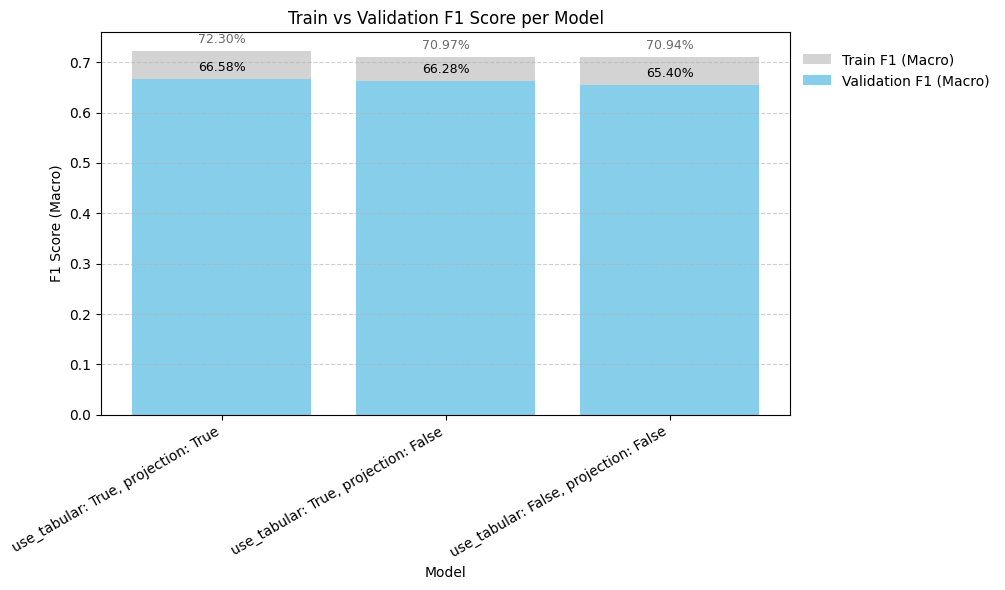

In [ ]:
plot_results(train_results, validation_results)

In [ ]:
train_results

[{'model': 'use_tabular: False, projection: False',
  'train_f1_score_macro': 0.6659552454948425,
  'train_f1_score_weighted': 0.6552110910415649,
  'train_loss': 2.253448963165283},
 {'model': 'use_tabular: True, projection: True',
  'train_f1_score_macro': 0.7286410927772522,
  'train_f1_score_weighted': 0.7126529812812805,
  'train_loss': 2.0463404655456543},
 {'model': 'use_tabular: True, projection: False',
  'train_f1_score_macro': 0.708656370639801,
  'train_f1_score_weighted': 0.6948457956314087,
  'train_loss': 2.075570821762085}]

> Using tabular features along with images improves the validation score by 1.2%; <br>
Adding a projection layers doesnt seem to benefit the validation score

# Batch size selection

In [ ]:
batch_sizes = [32, 64, 128, 224]

In [ ]:
train_results = []
validation_results = []

for batch_size in batch_sizes:
    print(f"✅ Batch size: {batch_size}")
    train_ds, val_ds, test_ds, classes = load_images(
        folder_name="../data", 
        batch_size=batch_size, 
        image_size=IMAGE_SIZE, 
        interpolation="bilinear",
        shuffle=False,
        random_seed=42)

    df_train = pd.read_csv("../data/metadata_train.csv")
    df_val = pd.read_csv("../data/metadata_val.csv")
    df_test = pd.read_csv("../data/metadata_test.csv")

    train_ds = merge_tabular_with_images(train_ds, train_tabular, batch_size, shuffle=True, shuffle_buffer=1000)
    val_ds = merge_tabular_with_images(val_ds, val_tabular, batch_size)
    test_ds = merge_tabular_with_images(test_ds, test_tabular, batch_size)

    model = build_model(
        input_shape=IMAGE_SHAPE,
        use_tabular=True,
        tabular_input_shape=(5,),
        project_tabular=False,
        use_data_augmentation=keras.layers.RandomRotation(factor=0.2, seed=42),
        base_model_name="EfficientNetB0",
        freeze_base=True,
        spatial_reduction="avg",
        dropout_rate=0.4,
        use_batch_norm=False,
        n_dense_extra_layers=0,
        n_dense_units=0, 
        activation="leaky_relu",
        kernel_regularizer_l2=1e-3,
        n_classes=202,
        output_activation="softmax",
    )

    model = compile_model(
        model,
        optimizer_name="RMSprop",
        learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, train_tabular.shape[0] / batch_size * EPOCHS * 0.6, alpha=0.2),
        weight_decay=1e-3,
        loss_name="CategoricalCrossentropy",
        label_smoothing=0.1,
        metrics=metrics
    )


    history = train_model(
        model,
        train_ds,
        val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=0
    )

    params = f"Batch size: {batch_size}"

    train_results, validation_results = store_results(train_results, validation_results, params)

✅ Batch size: 32
Found 8367 files belonging to 202 classes.
Found 1723 files belonging to 202 classes.
Found 1893 files belonging to 202 classes.


2025-04-27 20:59:24.999921: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-04-27 20:59:26.398290: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f8db8d80b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-27 20:59:26.398334: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-04-27 20:59:26.418071: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745787566.505681   31713 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1 - 63s | loss: 4.3869 - f1_score: 0.1131 | val_loss: 3.7556 - val_f1_score: 0.2467 | LR: 9.9945e-04
Epoch 2 - 9s | loss: 3.4574 - f1_score: 0.2890 | val_loss: 3.2144 - val_f1_score: 0.3762 | LR: 9.9780e-04
Epoch 3 - 9s | loss: 3.0477 - f1_score: 0.3940 | val_loss: 2.9658 - val_f1_score: 0.4403 | LR: 9.9506e-04
Epoch 4 - 9s | loss: 2.8303 - f1_score: 0.4732 | val_loss: 2.8117 - val_f1_score: 0.4870 | LR: 9.9122e-04
Epoch 5 - 8s | loss: 2.6802 - f1_score: 0.5193 | val_loss: 2.7126 - val_f1_score: 0.5115 | LR: 9.8632e-04
Epoch 6 - 10s | loss: 2.5739 - f1_score: 0.5527 | val_loss: 2.6470 - val_f1_score: 0.5285 | LR: 9.8034e-04
Epoch 7 - 9s | loss: 2.4889 - f1_score: 0.5798 | val_loss: 2.5976 - val_f1_score: 0.5346 | LR: 9.7333e-04
Epoch 8 - 10s | loss: 2.4378 - f1_score: 0.6019 | val_loss: 2.5699 - val_f1_score: 0.5396 | LR: 9.6528e-04
Epoch 9 - 8s | loss: 2.4008 - f1_score: 0.6128 | val_loss: 2.5287 - val_f1_score: 0.5558 | LR: 9.5623e-04
Epoch 10 - 10s | loss: 2.3496 - f1_score: 0

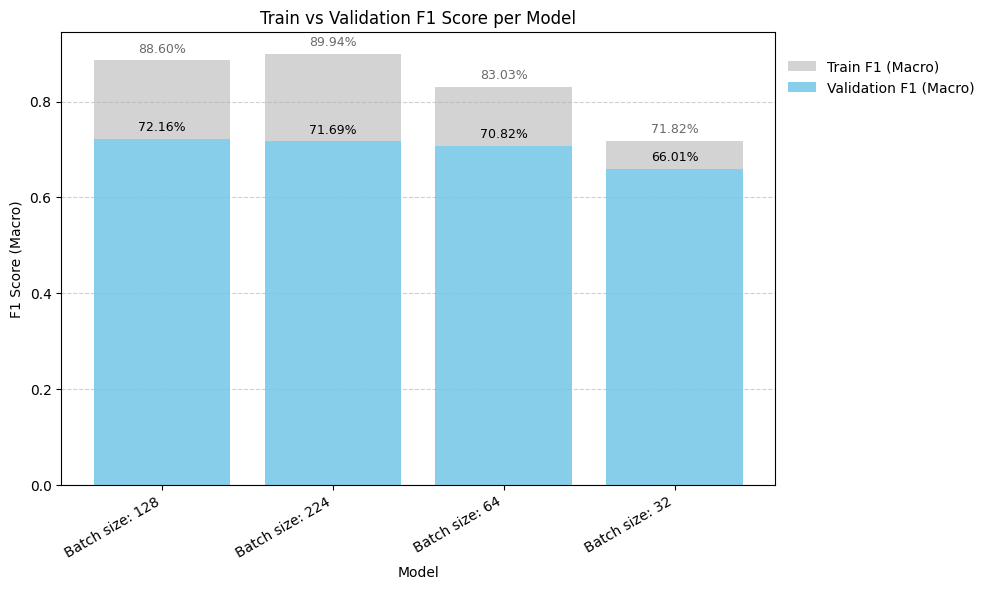

In [26]:
plot_results(train_results, validation_results)

> Best batch size is 128 

In [22]:
BATCH_SIZE = 128

# Augmentation selection

## Single augmentation without fine tuning

> We will try single augmentation techniques

In [ ]:
augmentation_layers = {
    "random_contrast": keras.layers.RandomContrast(factor=(0, 0.2), seed=42),
    
    "random_flip_hv": keras.layers.RandomFlip(mode="horizontal_and_vertical", seed=42),
    
    "random_flip_h": keras.layers.RandomFlip(mode="horizontal", seed=42),
    
    "rotation": keras.layers.RandomRotation(factor=(-0.2, 0.2), seed=42),
    
    "random_zoom": tf.keras.layers.RandomZoom(height_factor=(-0.2, 0.2), seed=42),
    
    "random_crop_resize":keras_cv.layers.RandomCropAndResize(target_size=(224, 224), crop_area_factor=(0.8, 1.0), aspect_ratio_factor=(3/4, 4/3), seed=42),
    
    "channel_shift": keras_cv.layers.RandomChannelShift(factor=(0, 0.2), seed=42, value_range=(0, 255)),
    
    "gaussian_blur": keras_cv.layers.RandomGaussianBlur(kernel_size=5, factor=(0, 0.2)),
    
    "random_hue": keras_cv.layers.RandomHue(factor=(0, 0.2), seed=42, value_range=(0, 255)),
    
    "none": None
}


In [73]:
train_results = []
validation_results = []

for aug_name, aug_layer in augmentation_layers.items():
    print(f"✅ Building model with augmentation: {aug_name}")

    model = build_model(
        input_shape=IMAGE_SHAPE,
        use_tabular=True,
        tabular_input_shape=(5,),
        project_tabular=False,
        use_data_augmentation=aug_layer,
        base_model_name="EfficientNetB0",
        freeze_base=True,
        spatial_reduction="avg",
        dropout_rate=0.4,
        use_batch_norm=False,
        n_dense_extra_layers=0,
        n_dense_units=0, 
        activation="leaky_relu",
        kernel_regularizer_l2=1e-3,
        n_classes=202,
        output_activation="softmax",
    )

    model = compile_model(
        model,
        optimizer_name="RMSprop",
        learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, train_tabular.shape[0] / BATCH_SIZE * EPOCHS * 0.6, alpha=0.2),
        weight_decay=1e-3,
        loss_name="CategoricalCrossentropy",
        label_smoothing=0.1,
        metrics=metrics
    )

    history = train_model(
        model,
        train_ds,
        val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=0
    )

    params = f"augmentation: {aug_name}"
    
    train_results, validation_results = store_results(train_results, validation_results, params)

✅ Building model with augmentation: random_contrast
Epoch 1 - 14s | loss: 4.2517 - f1_score: 0.2221 | val_loss: 3.5250 - val_f1_score: 0.2837 | LR: 9.9945e-04
Epoch 2 - 8s | loss: 3.1491 - f1_score: 0.3732 | val_loss: 2.9917 - val_f1_score: 0.3974 | LR: 9.9780e-04
Epoch 3 - 9s | loss: 2.6975 - f1_score: 0.4981 | val_loss: 2.7521 - val_f1_score: 0.4661 | LR: 9.9506e-04
Epoch 4 - 9s | loss: 2.4395 - f1_score: 0.5902 | val_loss: 2.6115 - val_f1_score: 0.5199 | LR: 9.9122e-04
Epoch 5 - 9s | loss: 2.2928 - f1_score: 0.6284 | val_loss: 2.5227 - val_f1_score: 0.5367 | LR: 9.8632e-04
Epoch 6 - 9s | loss: 2.1844 - f1_score: 0.6725 | val_loss: 2.4577 - val_f1_score: 0.5672 | LR: 9.8034e-04
Epoch 7 - 9s | loss: 2.0920 - f1_score: 0.7023 | val_loss: 2.4053 - val_f1_score: 0.5787 | LR: 9.7333e-04
Epoch 8 - 10s | loss: 2.0246 - f1_score: 0.7237 | val_loss: 2.3688 - val_f1_score: 0.5880 | LR: 9.6528e-04
Epoch 9 - 8s | loss: 1.9785 - f1_score: 0.7398 | val_loss: 2.3335 - val_f1_score: 0.5945 | LR: 9.5

2025-04-27 00:49:50.706173: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 11180835311943507419
2025-04-27 00:49:50.706281: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 644030249922898564
2025-04-27 00:49:50.706281: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 588852921238786664
2025-04-27 00:49:50.706281: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 2123227534840115846
2025-04-27 00:49:50.706281: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 18431001460198235302
2025-04-27 00:49:50.706281: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 17554018473790280998
2025-04-27 00:49:50.706281: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv it

2025-04-27 00:49:56.695851: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 13526933542268895760
2025-04-27 00:49:56.695922: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 11299629613528687966
2025-04-27 00:49:56.695935: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 642409308391937316
2025-04-27 00:49:56.695935: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 17280162566202548445
2025-04-27 00:49:56.695977: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 531380899302039861
2025-04-27 00:49:56.696003: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 17893636652420482794
2025-04-27 00:49:56.696024: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv i

Epoch 1 - 32s | loss: 4.2904 - f1_score: 0.2553 | val_loss: 3.6196 - val_f1_score: 0.2703 | LR: 9.9945e-04
Epoch 2 - 25s | loss: 3.2467 - f1_score: 0.3553 | val_loss: 3.0772 - val_f1_score: 0.3819 | LR: 9.9780e-04
Epoch 3 - 26s | loss: 2.8140 - f1_score: 0.4763 | val_loss: 2.8282 - val_f1_score: 0.4534 | LR: 9.9506e-04
Epoch 4 - 25s | loss: 2.5728 - f1_score: 0.5402 | val_loss: 2.7064 - val_f1_score: 0.4829 | LR: 9.9122e-04
Epoch 5 - 25s | loss: 2.4122 - f1_score: 0.5929 | val_loss: 2.6156 - val_f1_score: 0.5170 | LR: 9.8632e-04
Epoch 6 - 26s | loss: 2.3179 - f1_score: 0.6290 | val_loss: 2.5471 - val_f1_score: 0.5342 | LR: 9.8034e-04
Epoch 7 - 25s | loss: 2.2268 - f1_score: 0.6555 | val_loss: 2.5011 - val_f1_score: 0.5515 | LR: 9.7333e-04
Epoch 8 - 25s | loss: 2.1702 - f1_score: 0.6773 | val_loss: 2.4539 - val_f1_score: 0.5718 | LR: 9.6528e-04
Epoch 9 - 25s | loss: 2.1146 - f1_score: 0.6924 | val_loss: 2.4114 - val_f1_score: 0.5653 | LR: 9.5623e-04
Epoch 10 - 25s | loss: 2.0669 - f1_sc

2025-04-27 01:18:47.913116: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 4737799594721616343
2025-04-27 01:18:47.913198: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 2128539736882685585
2025-04-27 01:18:47.913198: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 2080371670213283359
2025-04-27 01:18:47.913252: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 233874445293057478
2025-04-27 01:18:47.913252: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 15003393675338803532
2025-04-27 01:18:47.913252: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 111050964313705182
2025-04-27 01:18:47.913283: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item

2025-04-27 01:18:55.677454: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 9080804792708313576
2025-04-27 01:18:55.677496: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 15360028974560525722
2025-04-27 01:18:55.677690: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 3303866680445047340
2025-04-27 01:18:55.677723: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 6443198453940411280
2025-04-27 01:18:55.677728: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 11720223498106319719
2025-04-27 01:18:55.677752: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 8194506399731479679
2025-04-27 01:18:55.677778: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv i

Epoch 1 - 44s | loss: 4.2855 - f1_score: 0.2556 | val_loss: 3.6044 - val_f1_score: 0.2529 | LR: 9.9945e-04
Epoch 2 - 33s | loss: 3.2203 - f1_score: 0.3538 | val_loss: 3.0586 - val_f1_score: 0.3865 | LR: 9.9780e-04
Epoch 3 - 33s | loss: 2.7808 - f1_score: 0.4800 | val_loss: 2.8249 - val_f1_score: 0.4618 | LR: 9.9506e-04
Epoch 4 - 33s | loss: 2.5373 - f1_score: 0.5542 | val_loss: 2.6825 - val_f1_score: 0.5004 | LR: 9.9122e-04
Epoch 5 - 34s | loss: 2.3829 - f1_score: 0.5991 | val_loss: 2.6067 - val_f1_score: 0.5187 | LR: 9.8632e-04
Epoch 6 - 33s | loss: 2.2723 - f1_score: 0.6381 | val_loss: 2.5311 - val_f1_score: 0.5310 | LR: 9.8034e-04
Epoch 7 - 34s | loss: 2.1943 - f1_score: 0.6686 | val_loss: 2.4800 - val_f1_score: 0.5413 | LR: 9.7333e-04
Epoch 8 - 38s | loss: 2.1308 - f1_score: 0.6870 | val_loss: 2.4501 - val_f1_score: 0.5605 | LR: 9.6528e-04
Epoch 9 - 33s | loss: 2.0765 - f1_score: 0.7035 | val_loss: 2.4253 - val_f1_score: 0.5761 | LR: 9.5623e-04
Epoch 10 - 38s | loss: 2.0448 - f1_sc

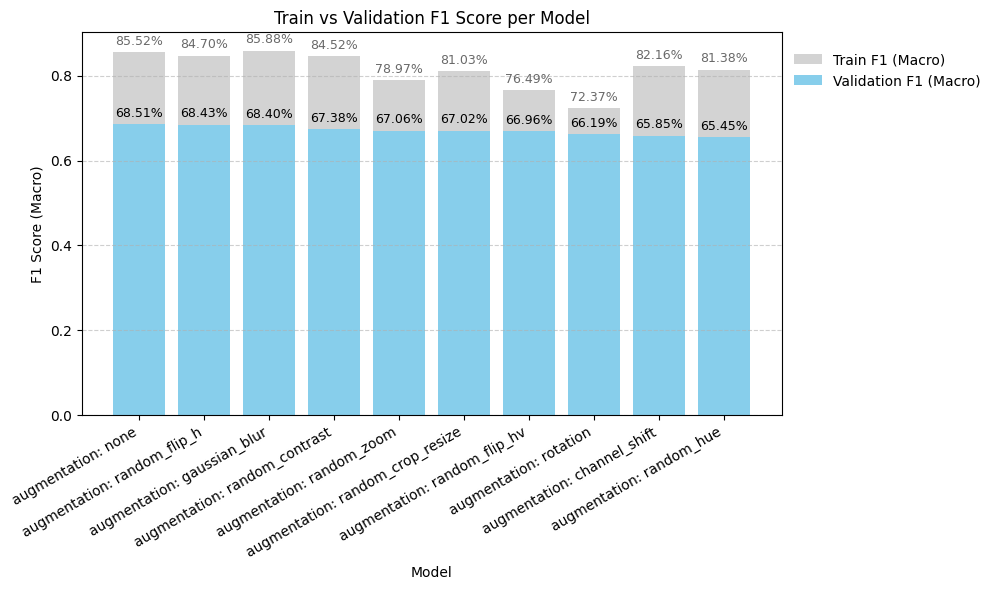

In [74]:
plot_results(train_results, validation_results)

> No agumentation can significantly improve the validation score during the initial train if base model is freezed <br>
Rotation decreases overfitting, but also decreases validation score by 2.5%

## Single augmentation only for fine tuning

> We will try single augmentation techniques only for fine tuning

In [23]:
print("✅ Training a clean model without augmentation...")

model = build_model(
    input_shape=IMAGE_SHAPE,
    use_tabular=True,
    tabular_input_shape=(5,),
    project_tabular=False,
    use_data_augmentation=None,  
    base_model_name="EfficientNetB0",
    freeze_base=True,
    spatial_reduction="avg",
    dropout_rate=0.4,
    use_batch_norm=False,
    n_dense_extra_layers=0,
    n_dense_units=0,
    activation="leaky_relu",
    kernel_regularizer_l2=1e-3,
    n_classes=202,
    output_activation="softmax",
)

model = compile_model(
    model,
    optimizer_name="RMSprop",
    learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, train_tabular.shape[0] / BATCH_SIZE * EPOCHS * 0.6, alpha=0.2),
    weight_decay=1e-3,
    loss_name="CategoricalCrossentropy",
    label_smoothing=0.1,
    metrics=metrics
)

history = train_model(
    model,
    train_ds,
    val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=0
)

# Optionally save the trained model
model.save("clean_model.h5")

✅ Training a clean model without augmentation...
16705208/16705208 [==============================] - 0s 0us/step


2025-04-29 13:51:48.702324: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-04-29 13:51:49.966696: I external/local_xla/xla/service/service.cc:168] XLA service 0x500c480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-29 13:51:49.966754: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-04-29 13:51:49.974147: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745934710.104108    3671 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1 - 68s | loss: 4.5573 - f1_score: 0.1173 | val_loss: 3.5645 - val_f1_score: 0.3008 | LR: 9.9780e-04
Epoch 2 - 8s | loss: 3.2028 - f1_score: 0.3673 | val_loss: 2.8814 - val_f1_score: 0.4229 | LR: 9.9122e-04
Epoch 3 - 8s | loss: 2.6495 - f1_score: 0.5115 | val_loss: 2.5895 - val_f1_score: 0.5060 | LR: 9.8034e-04
Epoch 4 - 8s | loss: 2.3609 - f1_score: 0.5985 | val_loss: 2.4288 - val_f1_score: 0.5581 | LR: 9.6528e-04
Epoch 5 - 8s | loss: 2.1774 - f1_score: 0.6614 | val_loss: 2.3299 - val_f1_score: 0.5821 | LR: 9.4620e-04
Epoch 6 - 7s | loss: 2.0423 - f1_score: 0.7082 | val_loss: 2.2595 - val_f1_score: 0.5966 | LR: 9.2331e-04
Epoch 7 - 8s | loss: 1.9574 - f1_score: 0.7393 | val_loss: 2.2068 - val_f1_score: 0.6039 | LR: 8.9686e-04
Epoch 8 - 8s | loss: 1.8875 - f1_score: 0.7640 | val_loss: 2.1635 - val_f1_score: 0.6226 | LR: 8.6715e-04
Epoch 9 - 8s | loss: 1.8212 - f1_score: 0.7881 | val_loss: 2.1274 - val_f1_score: 0.6395 | LR: 8.3449e-04
Epoch 10 - 8s | loss: 1.7758 - f1_score: 0.80

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


> We will use the trained model with no augmentation and test adding augmentation techniques for fine tuning. 

In [28]:
augmentation_layers = {
    "random_contrast": keras.layers.RandomContrast(factor=(0, 0.2), seed=42),
    
    "random_flip_h": keras.layers.RandomFlip(mode="horizontal", seed=42),
    
    "rotation": keras.layers.RandomRotation(factor=(-0.2, 0.2), seed=42),
    
    "random_zoom": tf.keras.layers.RandomZoom(height_factor=(-0.2, 0.2), seed=42),
        
    "gaussian_blur": keras_cv.layers.RandomGaussianBlur(kernel_size=7, factor=(0, 0.2)),
        
    "none": None
}

In [ ]:
best_epoch = get_best_epoch()
print(f"Best epoch: {best_epoch}")


Best epoch: 67


In [37]:
train_results = []
validation_results = []

for aug_name, aug_layer in augmentation_layers.items():
    
    print(f"✅ Fine-tuning with augmentation: {aug_name}")
    
    fine_tune_model = keras.models.load_model("clean_model.h5", compile=False)

    new_input = keras.Input(shape=IMAGE_SHAPE, name="image_input")
    x_aug = aug_layer(new_input) if aug_layer else new_input  
    x_aug = fine_tune_model.get_layer("efficientnetb0")(x_aug)  

    tabular_input = fine_tune_model.get_layer("tabular_input").input

    x_pool = fine_tune_model.get_layer("global_average_pooling2d_1")(x_aug)
    x_concat = fine_tune_model.get_layer("concatenate_3")([x_pool, tabular_input])
    x_dropout = fine_tune_model.get_layer("dropout_3")(x_concat)
    outputs = fine_tune_model.get_layer("dense_3")(x_dropout)

    fine_tune_model = keras.Model(inputs=[new_input, tabular_input], outputs=outputs)
    
    unfreeze_model_layers(fine_tune_model.get_layer('efficientnetb0'), "block7")

    fine_tune_model = compile_model(
        fine_tune_model,
        optimizer_name="Adam",
        learning_rate=keras.optimizers.schedules.CosineDecay(1e-5, train_tabular.shape[0] / BATCH_SIZE * 100 * 0.7, alpha=0.4),
        weight_decay=1e-3,
        loss_name="CategoricalCrossentropy",
        label_smoothing=0.1,
        metrics=metrics
    )
    
    fine_tune_model.summary()

    # Fine-tune
    history_fine = fine_tune_model.fit(
        train_ds,
        epochs=best_epoch + 100,
        initial_epoch=best_epoch,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=0
    )

    params = f"augmentation: {aug_name}"
    train_results, validation_results = store_results(train_results, validation_results, params)


✅ Fine-tuning with augmentation: random_contrast
Unfreezed from layer: block7a_expand_conv, not including BatchNorm layers
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image_input (InputLayer)    [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 random_contrast_3 (RandomC  (None, 224, 224, 3)          0         ['image_input[0][0]']         
 ontrast)                                                                                         
                                                                                                  
 efficientnetb0 (Functional  (None, 7, 7, 1280)           4049571   ['random_contrast_3[4][0]']   
 )                                                                  

2025-04-27 13:39:19.033724: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_3/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 65 - 15s | loss: 1.5602 - f1_score: 0.8677 | val_loss: 1.9090 - val_f1_score: 0.6958 | LR: 9.9970e-06
Epoch 66 - 9s | loss: 1.5003 - f1_score: 0.8770 | val_loss: 1.8905 - val_f1_score: 0.6957 | LR: 9.9879e-06
Epoch 67 - 9s | loss: 1.5004 - f1_score: 0.8721 | val_loss: 1.8809 - val_f1_score: 0.6970 | LR: 9.9728e-06
Epoch 68 - 9s | loss: 1.4613 - f1_score: 0.8835 | val_loss: 1.8745 - val_f1_score: 0.6977 | LR: 9.9517e-06
Epoch 69 - 9s | loss: 1.4602 - f1_score: 0.8860 | val_loss: 1.8665 - val_f1_score: 0.6998 | LR: 9.9246e-06
Epoch 70 - 9s | loss: 1.4443 - f1_score: 0.8881 | val_loss: 1.8618 - val_f1_score: 0.7009 | LR: 9.8916e-06
Epoch 71 - 9s | loss: 1.4252 - f1_score: 0.8935 | val_loss: 1.8557 - val_f1_score: 0.7068 | LR: 9.8527e-06
Epoch 72 - 9s | loss: 1.4237 - f1_score: 0.8951 | val_loss: 1.8507 - val_f1_score: 0.7080 | LR: 9.8081e-06
Epoch 73 - 10s | loss: 1.4039 - f1_score: 0.8998 | val_loss: 1.8477 - val_f1_score: 0.7073 | LR: 9.7578e-06
Epoch 74 - 9s | loss: 1.3928 - f1_s

2025-04-27 13:55:06.938507: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_4/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 65 - 16s | loss: 1.5783 - f1_score: 0.8386 | val_loss: 1.9076 - val_f1_score: 0.6941 | LR: 9.9970e-06
Epoch 66 - 9s | loss: 1.5342 - f1_score: 0.8609 | val_loss: 1.8889 - val_f1_score: 0.6954 | LR: 9.9879e-06
Epoch 67 - 10s | loss: 1.5206 - f1_score: 0.8614 | val_loss: 1.8797 - val_f1_score: 0.6978 | LR: 9.9728e-06
Epoch 68 - 9s | loss: 1.4921 - f1_score: 0.8721 | val_loss: 1.8718 - val_f1_score: 0.6996 | LR: 9.9517e-06
Epoch 69 - 9s | loss: 1.4707 - f1_score: 0.8755 | val_loss: 1.8659 - val_f1_score: 0.7031 | LR: 9.9246e-06
Epoch 70 - 9s | loss: 1.4718 - f1_score: 0.8802 | val_loss: 1.8584 - val_f1_score: 0.7060 | LR: 9.8916e-06
Epoch 71 - 9s | loss: 1.4493 - f1_score: 0.8856 | val_loss: 1.8539 - val_f1_score: 0.7080 | LR: 9.8527e-06
Epoch 72 - 9s | loss: 1.4340 - f1_score: 0.8915 | val_loss: 1.8495 - val_f1_score: 0.7082 | LR: 9.8081e-06
Epoch 73 - 9s | loss: 1.4215 - f1_score: 0.8936 | val_loss: 1.8451 - val_f1_score: 0.7110 | LR: 9.7578e-06
Epoch 74 - 9s | loss: 1.4011 - f1_s

...

Epoch 65 - 16s | loss: 1.7564 - f1_score: 0.7957 | val_loss: 1.9095 - val_f1_score: 0.6943 | LR: 9.9970e-06
Epoch 66 - 9s | loss: 1.7008 - f1_score: 0.8101 | val_loss: 1.8924 - val_f1_score: 0.6975 | LR: 9.9879e-06
Epoch 67 - 9s | loss: 1.6793 - f1_score: 0.8182 | val_loss: 1.8819 - val_f1_score: 0.6970 | LR: 9.9728e-06
Epoch 68 - 9s | loss: 1.6517 - f1_score: 0.8275 | val_loss: 1.8747 - val_f1_score: 0.7045 | LR: 9.9517e-06
Epoch 69 - 9s | loss: 1.6332 - f1_score: 0.8285 | val_loss: 1.8689 - val_f1_score: 0.7063 | LR: 9.9246e-06
Epoch 70 - 9s | loss: 1.5989 - f1_score: 0.8384 | val_loss: 1.8637 - val_f1_score: 0.7076 | LR: 9.8916e-06
Epoch 71 - 9s | loss: 1.6076 - f1_score: 0.8327 | val_loss: 1.8589 - val_f1_score: 0.7124 | LR: 9.8527e-06
Epoch 72 - 9s | loss: 1.5876 - f1_score: 0.8429 | val_loss: 1.8548 - val_f1_score: 0.7132 | LR: 9.8081e-06
Epoch 73 - 9s | loss: 1.5703 - f1_score: 0.8448 | val_loss: 1.8511 - val_f1_score: 0.7143 | LR: 9.7578e-06
Epoch 74 - 10s | loss: 1.5510 - f1_s

2025-04-27 14:43:08.742284: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_7/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 65 - 17s | loss: 1.5581 - f1_score: 0.8452 | val_loss: 1.9096 - val_f1_score: 0.6917 | LR: 9.9970e-06
Epoch 66 - 9s | loss: 1.5057 - f1_score: 0.8738 | val_loss: 1.8923 - val_f1_score: 0.6936 | LR: 9.9879e-06
Epoch 67 - 10s | loss: 1.4890 - f1_score: 0.8751 | val_loss: 1.8804 - val_f1_score: 0.6956 | LR: 9.9728e-06
Epoch 68 - 9s | loss: 1.4520 - f1_score: 0.8925 | val_loss: 1.8735 - val_f1_score: 0.6989 | LR: 9.9517e-06
Epoch 69 - 9s | loss: 1.4530 - f1_score: 0.8929 | val_loss: 1.8666 - val_f1_score: 0.6999 | LR: 9.9246e-06
Epoch 70 - 9s | loss: 1.4239 - f1_score: 0.8967 | val_loss: 1.8606 - val_f1_score: 0.7044 | LR: 9.8916e-06
Epoch 71 - 9s | loss: 1.4276 - f1_score: 0.8956 | val_loss: 1.8552 - val_f1_score: 0.7052 | LR: 9.8527e-06
Epoch 72 - 9s | loss: 1.4182 - f1_score: 0.8946 | val_loss: 1.8496 - val_f1_score: 0.7072 | LR: 9.8081e-06
Epoch 73 - 9s | loss: 1.3933 - f1_score: 0.9051 | val_loss: 1.8463 - val_f1_score: 0.7083 | LR: 9.7578e-06
Epoch 74 - 9s | loss: 1.3998 - f1_s

2025-04-27 14:59:12.893615: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_8/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 65 - 15s | loss: 1.5538 - f1_score: 0.8487 | val_loss: 1.9091 - val_f1_score: 0.6916 | LR: 9.9970e-06
Epoch 66 - 9s | loss: 1.5089 - f1_score: 0.8671 | val_loss: 1.8904 - val_f1_score: 0.6952 | LR: 9.9879e-06
Epoch 67 - 9s | loss: 1.4775 - f1_score: 0.8813 | val_loss: 1.8809 - val_f1_score: 0.6989 | LR: 9.9728e-06
Epoch 68 - 9s | loss: 1.4641 - f1_score: 0.8898 | val_loss: 1.8719 - val_f1_score: 0.7001 | LR: 9.9517e-06
Epoch 69 - 9s | loss: 1.4490 - f1_score: 0.8906 | val_loss: 1.8654 - val_f1_score: 0.7021 | LR: 9.9246e-06
Epoch 70 - 9s | loss: 1.4485 - f1_score: 0.8873 | val_loss: 1.8599 - val_f1_score: 0.7043 | LR: 9.8916e-06
Epoch 71 - 9s | loss: 1.4272 - f1_score: 0.8944 | val_loss: 1.8544 - val_f1_score: 0.7071 | LR: 9.8527e-06
Epoch 72 - 9s | loss: 1.4235 - f1_score: 0.8931 | val_loss: 1.8509 - val_f1_score: 0.7108 | LR: 9.8081e-06
Epoch 73 - 9s | loss: 1.3991 - f1_score: 0.9030 | val_loss: 1.8460 - val_f1_score: 0.7086 | LR: 9.7578e-06
Epoch 74 - 9s | loss: 1.3882 - f1_sc

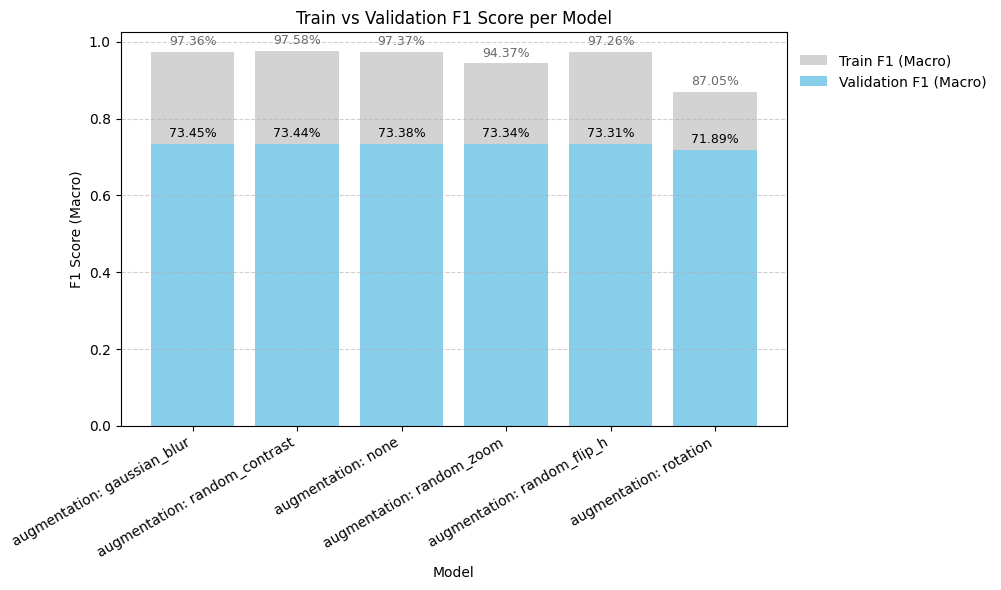

In [38]:
plot_results(train_results, validation_results)

> No augmentation layers seem to improve significantly the performance for fine tuning

## Combined augmentation only for fine tuning

In [24]:
combined_augmentation = {
    "manual_combined": tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal", seed=42),
        keras_cv.layers.RandomGaussianBlur(kernel_size=7, factor=(0.0, 0.2)),
        tf.keras.layers.RandomContrast(factor=(0.0, 0.2), seed=42),
        tf.keras.layers.RandomZoom(height_factor=(-0.2, 0.2), seed=42),
    ]),
    
    "randaugment": keras_cv.layers.RandAugment(magnitude=0.2, augmentations_per_image=2, seed=42, value_range=(0, 255)),
    
    "none": None
}

In [25]:
train_results = []
validation_results = []

for aug_name, aug_layer in combined_augmentation.items():
    
    print(f"✅ Fine-tuning with combination augmentation: {aug_name}")
    
    fine_tune_model = keras.models.load_model("clean_model.h5", compile=False)
    
    for layer in fine_tune_model.layers:
        if layer.name.startswith("efficientnet"):
            base_model_name = layer.name
        elif layer.name.startswith("global_average_pooling2d"):
            global_name = layer.name
        elif layer.name.startswith("concatenate"):
            concat_name = layer.name
        elif layer.name.startswith("dropout"):
            dropout_name = layer.name
        elif layer.name.startswith("dense"):
            dense_name = layer.name
            
    new_input = keras.Input(shape=IMAGE_SHAPE, name="image_input")
    x_aug = aug_layer(new_input) if aug_layer else new_input  
    x_aug = fine_tune_model.get_layer(base_model_name)(x_aug)  

    tabular_input = fine_tune_model.get_layer("tabular_input").input

    x_pool = fine_tune_model.get_layer(global_name)(x_aug)
    x_concat = fine_tune_model.get_layer(concat_name)([x_pool, tabular_input])
    x_dropout = fine_tune_model.get_layer(dropout_name)(x_concat)
    outputs = fine_tune_model.get_layer(dense_name)(x_dropout)

    fine_tune_model = keras.Model(inputs=[new_input, tabular_input], outputs=outputs)
        
    unfreeze_model_layers(fine_tune_model.get_layer(base_model_name), "block7")

    fine_tune_model = compile_model(
        fine_tune_model,
        optimizer_name="Adam",
        learning_rate=keras.optimizers.schedules.CosineDecay(1e-5, train_tabular.shape[0] / BATCH_SIZE * 100 * 0.8, alpha=0.5),
        weight_decay=1e-3,
        loss_name="CategoricalCrossentropy",
        label_smoothing=0.1,
        metrics=metrics
    )
    
    fine_tune_model.summary()

    # Fine-tune
    history_fine = fine_tune_model.fit(
        train_ds,
        epochs=best_epoch + 100,
        initial_epoch=best_epoch,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=0
    )

    params = f"augmentation: {aug_name}"
    train_results, validation_results = store_results(train_results, validation_results, params)

✅ Fine-tuning with combination augmentation: manual_combined
Unfreezed from layer: block7a_expand_conv, not including BatchNorm layers
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image_input (InputLayer)    [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 sequential (Sequential)     (None, 224, 224, 3)          0         ['image_input[0][0]']         
                                                                                                  
 efficientnetb0 (Functional  (None, 7, 7, 1280)           4049571   ['sequential[0][0]']          
 )                                                                                                
                                                          

2025-04-29 15:00:15.873838: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-04-29 15:00:21.124482: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-04-29 15:00:22.682281: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fbf601d4f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-29 15:00:22.682454: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-04-29 15:00:22.702240: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745938822.815054     128 device_compiler.h:186] Compiled cluster 

Epoch 68 - 70s | loss: 1.5819 - f1_score: 0.8554 | val_loss: 1.8453 - val_f1_score: 0.7187 | LR: 9.9981e-06
Epoch 69 - 9s | loss: 1.5394 - f1_score: 0.8646 | val_loss: 1.8360 - val_f1_score: 0.7209 | LR: 9.9923e-06
Epoch 70 - 9s | loss: 1.5166 - f1_score: 0.8686 | val_loss: 1.8314 - val_f1_score: 0.7214 | LR: 9.9827e-06
Epoch 71 - 9s | loss: 1.5007 - f1_score: 0.8773 | val_loss: 1.8276 - val_f1_score: 0.7220 | LR: 9.9692e-06
Epoch 72 - 9s | loss: 1.4982 - f1_score: 0.8721 | val_loss: 1.8240 - val_f1_score: 0.7212 | LR: 9.9519e-06
Epoch 73 - 9s | loss: 1.4862 - f1_score: 0.8760 | val_loss: 1.8214 - val_f1_score: 0.7226 | LR: 9.9308e-06
Epoch 74 - 9s | loss: 1.4846 - f1_score: 0.8750 | val_loss: 1.8197 - val_f1_score: 0.7207 | LR: 9.9060e-06
Epoch 75 - 9s | loss: 1.4761 - f1_score: 0.8802 | val_loss: 1.8167 - val_f1_score: 0.7231 | LR: 9.8774e-06
Epoch 76 - 9s | loss: 1.4661 - f1_score: 0.8839 | val_loss: 1.8143 - val_f1_score: 0.7233 | LR: 9.8451e-06
Epoch 77 - 9s | loss: 1.4650 - f1_sc

2025-04-29 15:15:21.778883: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_1/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-04-29 15:15:43.378718: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 14238420022865997306
2025-04-29 15:15:43.378798: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 6421862513930244212
2025-04-29 15:15:43.378818: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 12338470322166148020
2025-04-29 15:15:43.378818: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 13438598038867108099
2025-04-29 15:15:43.378875: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled.

Epoch 68 - 37s | loss: 1.6887 - f1_score: 0.8153 | val_loss: 2.0700 - val_f1_score: 0.6576 | LR: 9.9981e-06
Epoch 69 - 26s | loss: 1.6611 - f1_score: 0.8309 | val_loss: 2.0323 - val_f1_score: 0.6706 | LR: 9.9923e-06
Epoch 70 - 25s | loss: 1.6253 - f1_score: 0.8378 | val_loss: 2.0054 - val_f1_score: 0.6654 | LR: 9.9827e-06
Epoch 71 - 25s | loss: 1.6283 - f1_score: 0.8324 | val_loss: 2.0213 - val_f1_score: 0.6534 | LR: 9.9692e-06
Epoch 72 - 25s | loss: 1.6166 - f1_score: 0.8397 | val_loss: 2.0127 - val_f1_score: 0.6619 | LR: 9.9519e-06
Epoch 73 - 24s | loss: 1.6092 - f1_score: 0.8459 | val_loss: 1.9822 - val_f1_score: 0.6658 | LR: 9.9308e-06
Epoch 74 - 24s | loss: 1.5900 - f1_score: 0.8427 | val_loss: 1.9781 - val_f1_score: 0.6693 | LR: 9.9060e-06
Epoch 75 - 24s | loss: 1.5849 - f1_score: 0.8484 | val_loss: 2.0058 - val_f1_score: 0.6790 | LR: 9.8774e-06
Epoch 76 - 24s | loss: 1.5893 - f1_score: 0.8436 | val_loss: 1.9857 - val_f1_score: 0.6822 | LR: 9.8451e-06
Epoch 77 - 25s | loss: 1.572

2025-04-29 15:23:51.349012: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_2/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 68 - 15s | loss: 1.3710 - f1_score: 0.8832 | val_loss: 1.8455 - val_f1_score: 0.7230 | LR: 9.9981e-06
Epoch 69 - 8s | loss: 1.3506 - f1_score: 0.9211 | val_loss: 1.8336 - val_f1_score: 0.7198 | LR: 9.9923e-06
Epoch 70 - 8s | loss: 1.3460 - f1_score: 0.9264 | val_loss: 1.8276 - val_f1_score: 0.7222 | LR: 9.9827e-06
Epoch 71 - 8s | loss: 1.3336 - f1_score: 0.9270 | val_loss: 1.8215 - val_f1_score: 0.7254 | LR: 9.9692e-06
Epoch 72 - 8s | loss: 1.3167 - f1_score: 0.9302 | val_loss: 1.8186 - val_f1_score: 0.7259 | LR: 9.9519e-06
Epoch 73 - 8s | loss: 1.3223 - f1_score: 0.9292 | val_loss: 1.8159 - val_f1_score: 0.7269 | LR: 9.9308e-06
Epoch 74 - 8s | loss: 1.3046 - f1_score: 0.9329 | val_loss: 1.8130 - val_f1_score: 0.7272 | LR: 9.9060e-06
Epoch 75 - 8s | loss: 1.3105 - f1_score: 0.9266 | val_loss: 1.8106 - val_f1_score: 0.7284 | LR: 9.8774e-06
Epoch 76 - 8s | loss: 1.2916 - f1_score: 0.9384 | val_loss: 1.8079 - val_f1_score: 0.7290 | LR: 9.8451e-06
Epoch 77 - 8s | loss: 1.2926 - f1_sc

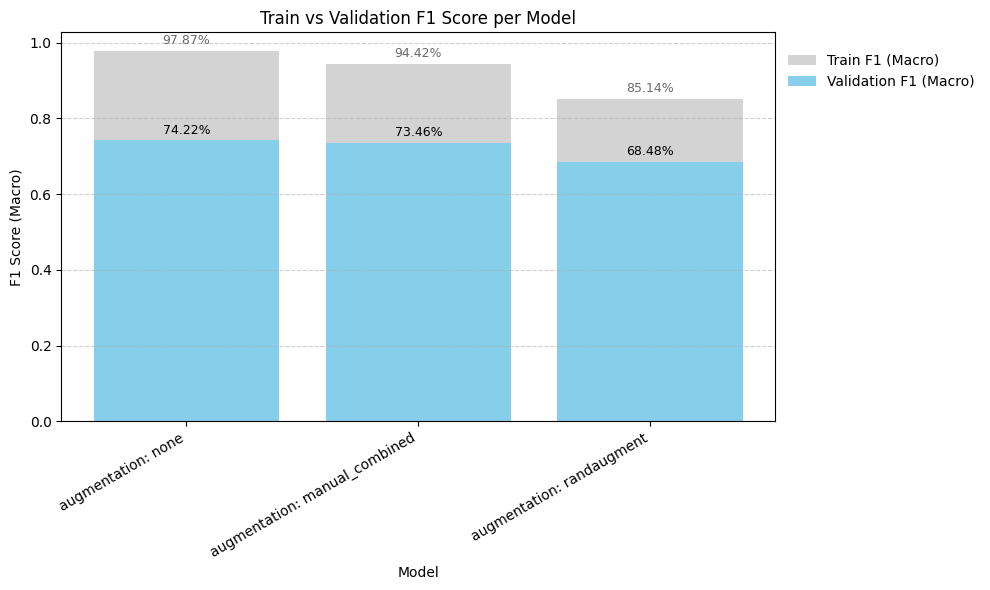

In [26]:
plot_results(train_results, validation_results)

> No augmentation improves validation f1 score  

In [23]:
aug_layer = None

# Base model Selection

## Base model selection without fine tuning

> We will compare transfer learning with these models; and select the top 3 for fine tuning

In [24]:
models = [
    "Xception", 
    "ResNet50V2", 
    "InceptionV3", 
    "DenseNet121", 
    "EfficientNetB0",
    "EfficientNetV2B1",
    "EfficientNetV2S", 
    "ConvNeXtTiny"
    ]

In [25]:
train_results = []
validation_results = []

for model_ in models:
    print(f"✅ Model: {model_}")
    model = build_model(
        input_shape=IMAGE_SHAPE,
        use_tabular=True,
        tabular_input_shape=(5,),
        project_tabular=False,
        use_data_augmentation=aug_layer,
        base_model_name=model_,
        freeze_base=True,
        spatial_reduction="avg",
        dropout_rate=0.4,
        use_batch_norm=False,
        n_dense_extra_layers=0,
        n_dense_units=0, # 256,
        activation=None,
        kernel_regularizer_l2=0,
        n_classes=202,
        output_activation="softmax",
    )

    model = compile_model(
        model,
        optimizer_name="RMSprop",
        learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, train_tabular.shape[0] / BATCH_SIZE * EPOCHS * 0.6, alpha=0.2),
        weight_decay=1e-3,
        loss_name="CategoricalCrossentropy",
        label_smoothing=0.1,
        metrics=metrics,
    )


    history = train_model(
        model,
        train_ds,
        val_ds,
        epochs=100,
        callbacks=callbacks,
        verbose=0
    )
    
    params = f"{model_}"
    
    train_results, validation_results = store_results(train_results, validation_results, params)


✅ Model: Xception
83683744/83683744 [==============================] - 1s 0us/step


2025-04-29 17:49:44.913056: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-04-29 17:49:46.925183: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fa0848f7000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-29 17:49:46.925220: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-04-29 17:49:46.941879: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745948987.032560     124 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-04-29 17:50:27.162766: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 5325136425687739257
2025-04-29 17:50:27.162822: I tensorflow/core/framewor

Epoch 1 - 62s | loss: 3.8894 - f1_score: 0.1581 | val_loss: 3.7991 - val_f1_score: 0.2308 | LR: 9.9780e-04
Epoch 2 - 11s | loss: 2.5617 - f1_score: 0.4975 | val_loss: 3.1599 - val_f1_score: 0.3390 | LR: 9.9122e-04
Epoch 3 - 10s | loss: 2.1725 - f1_score: 0.6290 | val_loss: 2.9339 - val_f1_score: 0.3935 | LR: 9.8034e-04
Epoch 4 - 11s | loss: 1.9787 - f1_score: 0.6970 | val_loss: 2.8299 - val_f1_score: 0.4252 | LR: 9.6528e-04
Epoch 5 - 11s | loss: 1.8575 - f1_score: 0.7495 | val_loss: 2.7495 - val_f1_score: 0.4465 | LR: 9.4620e-04
Epoch 6 - 11s | loss: 1.7639 - f1_score: 0.7845 | val_loss: 2.6955 - val_f1_score: 0.4694 | LR: 9.2331e-04
Epoch 7 - 11s | loss: 1.6998 - f1_score: 0.8093 | val_loss: 2.6585 - val_f1_score: 0.4741 | LR: 8.9686e-04
Epoch 8 - 11s | loss: 1.6534 - f1_score: 0.8277 | val_loss: 2.6275 - val_f1_score: 0.4772 | LR: 8.6715e-04
Epoch 9 - 11s | loss: 1.6066 - f1_score: 0.8448 | val_loss: 2.6081 - val_f1_score: 0.4913 | LR: 8.3449e-04
Epoch 10 - 11s | loss: 1.5744 - f1_sc

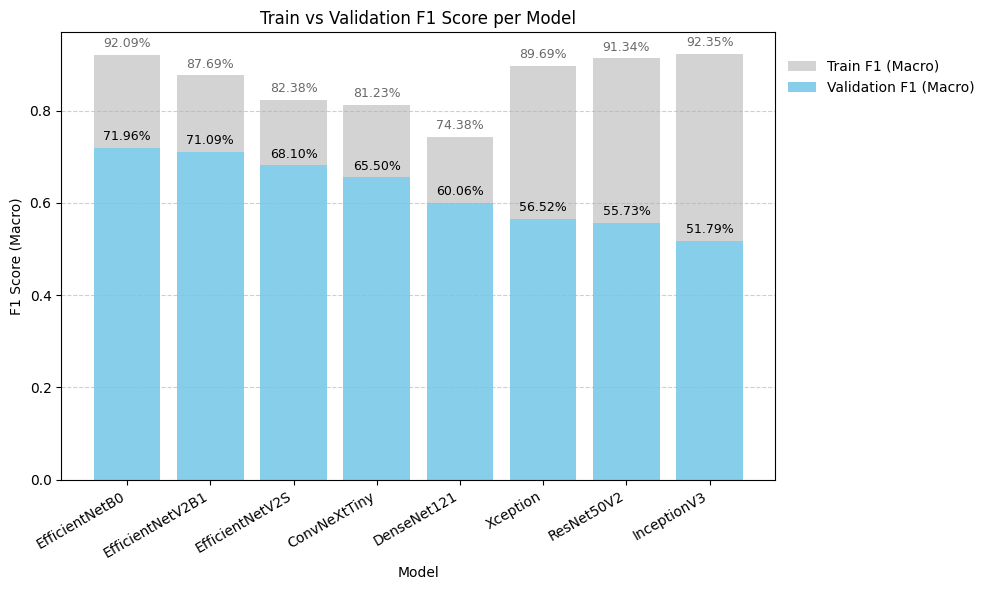

In [26]:
plot_results(train_results, validation_results)

## Base model selection with fine tuning

In [57]:
hyper_models = [
    "EfficientNetV2B1",
    "EfficientNetB0",
]

In [ ]:
best_epoch = []

for model_name in hyper_models: 
    print(f"✅ Training a model {model_name} without augmentation...")

    model = build_model(
        input_shape=IMAGE_SHAPE,
        use_tabular=True,
        tabular_input_shape=(5,),
        project_tabular=False,
        use_data_augmentation=None, 
        base_model_name=model_name,
        freeze_base=True,
        spatial_reduction="avg",
        dropout_rate=0.4,
        use_batch_norm=False,
        n_dense_extra_layers=0,
        n_dense_units=0,
        activation="leaky_relu",
        kernel_regularizer_l2=1e-3,
        n_classes=202,
        output_activation="softmax",
    )

    model = compile_model(
        model,
        optimizer_name="RMSprop",
        learning_rate=keras.optimizers.schedules.CosineDecay(1e-3, train_tabular.shape[0] / BATCH_SIZE * EPOCHS * 0.6, alpha=0.2),
        weight_decay=1e-3,
        loss_name="CategoricalCrossentropy",
        label_smoothing=0.1,
        metrics=metrics
    )

    history = train_model(
        model,
        train_ds,
        val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=0
    )
    
    best_epoch.append(get_best_epoch())
    # Optionally save the trained model
    model.save(f"clean_model_{model_name}.h5")

✅ Training a model EfficientNetB0 without augmentation...
Epoch 1 - 15s | loss: 4.5391 - f1_score: 0.2431 | val_loss: 3.5706 - val_f1_score: 0.2893 | LR: 9.9945e-04
Epoch 2 - 8s | loss: 3.2140 - f1_score: 0.3662 | val_loss: 2.8850 - val_f1_score: 0.4249 | LR: 9.9780e-04
Epoch 3 - 8s | loss: 2.6573 - f1_score: 0.5027 | val_loss: 2.5905 - val_f1_score: 0.5071 | LR: 9.9506e-04
Epoch 4 - 8s | loss: 2.3565 - f1_score: 0.6011 | val_loss: 2.4312 - val_f1_score: 0.5538 | LR: 9.9122e-04
Epoch 5 - 8s | loss: 2.1660 - f1_score: 0.6644 | val_loss: 2.3353 - val_f1_score: 0.5869 | LR: 9.8632e-04
Epoch 6 - 8s | loss: 2.0387 - f1_score: 0.7117 | val_loss: 2.2666 - val_f1_score: 0.6002 | LR: 9.8034e-04
Epoch 7 - 8s | loss: 1.9428 - f1_score: 0.7357 | val_loss: 2.2146 - val_f1_score: 0.6140 | LR: 9.7333e-04
Epoch 8 - 8s | loss: 1.8708 - f1_score: 0.7668 | val_loss: 2.1710 - val_f1_score: 0.6219 | LR: 9.6528e-04
Epoch 9 - 8s | loss: 1.8048 - f1_score: 0.7873 | val_loss: 2.1425 - val_f1_score: 0.6365 | LR

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Training a model EfficientNetV2B1 without augmentation...
28456008/28456008 [==============================] - 0s 0us/step
Epoch 1 - 18s | loss: 4.5180 - f1_score: 0.2465 | val_loss: 3.4847 - val_f1_score: 0.3221 | LR: 9.9945e-04
Epoch 2 - 7s | loss: 3.1770 - f1_score: 0.3529 | val_loss: 2.7865 - val_f1_score: 0.4466 | LR: 9.9780e-04
Epoch 3 - 8s | loss: 2.6440 - f1_score: 0.4842 | val_loss: 2.4944 - val_f1_score: 0.5039 | LR: 9.9506e-04
Epoch 4 - 8s | loss: 2.3753 - f1_score: 0.5664 | val_loss: 2.3431 - val_f1_score: 0.5517 | LR: 9.9122e-04
Epoch 5 - 7s | loss: 2.2063 - f1_score: 0.6199 | val_loss: 2.2518 - val_f1_score: 0.5856 | LR: 9.8632e-04
Epoch 6 - 7s | loss: 2.0802 - f1_score: 0.6653 | val_loss: 2.1913 - val_f1_score: 0.5977 | LR: 9.8034e-04
Epoch 7 - 7s | loss: 1.9966 - f1_score: 0.6974 | val_loss: 2.1444 - val_f1_score: 0.6063 | LR: 9.7333e-04
Epoch 8 - 7s | loss: 1.9268 - f1_score: 0.7229 | val_loss: 2.1029 - val_f1_score: 0.6164 | LR: 9.6528e-04
Epoch 9 - 7s | loss: 1.876

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [51]:
best_epoch

[70, 78]

In [37]:
aug_layer

In [58]:
train_results = []
validation_results = []

for i, model_name in enumerate(hyper_models):
    print(f"✅ Fine-tuning with combination augmentation: {model_name}")
    
    fine_tune_model = keras.models.load_model(f"clean_model_{model_name}.h5", compile=False)
    
    for layer in fine_tune_model.layers:
        
        if layer.name.startswith("global_average_pooling2d"):
            global_name = layer.name
        elif layer.name.startswith("concatenate"):
            concat_name = layer.name
        elif layer.name.startswith("dropout"):
            dropout_name = layer.name
        elif layer.name.startswith("dense"):
            dense_name = layer.name
        elif layer.name.startswith("efficientnet"):
            base_model_name = layer.name
                
    new_input = keras.Input(shape=IMAGE_SHAPE, name="image_input")
    x_aug = aug_layer(new_input) if aug_layer else new_input  
    x_aug = fine_tune_model.get_layer(base_model_name)(x_aug)  

    tabular_input = fine_tune_model.get_layer("tabular_input").input
    
    
    x_pool = fine_tune_model.get_layer(global_name)(x_aug)
    x_concat = fine_tune_model.get_layer(concat_name)([x_pool, tabular_input])
    x_dropout = fine_tune_model.get_layer(dropout_name)(x_concat)
    outputs = fine_tune_model.get_layer(dense_name)(x_dropout)

    fine_tune_model = keras.Model(inputs=[new_input, tabular_input], outputs=outputs)
    
    if model_name == "EfficientNetB0":
        unfreeze_model_layers(fine_tune_model.get_layer(base_model_name), "block7")
    elif model_name == "EfficientNetV2B1":  
        unfreeze_model_layers(fine_tune_model.get_layer(base_model_name), "block6")

    fine_tune_model = compile_model(
        fine_tune_model,
        optimizer_name="Adam",
        learning_rate=keras.optimizers.schedules.CosineDecay(1e-5, train_tabular.shape[0] / BATCH_SIZE * 100 * 0.9, alpha=0.5),
        weight_decay=1e-3,
        loss_name="CategoricalCrossentropy",
        label_smoothing=0.1,
        metrics=metrics
    )
    
    fine_tune_model.summary()

    # Fine-tune
    history_fine = fine_tune_model.fit(
        train_ds,
        epochs=best_epoch[i] + 100,
        initial_epoch=best_epoch[i],
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=0
    )

    params = f"model {model_name}"
    train_results, validation_results = store_results(train_results, validation_results, params)

✅ Fine-tuning with combination augmentation: EfficientNetV2B1
Unfreezed from layer: block6a_expand_conv, not including BatchNorm layers
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image_input (InputLayer)    [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 sequential_1 (Sequential)   (None, 224, 224, 3)          0         ['image_input[0][0]']         
                                                                                                  
 efficientnetv2-b1 (Functio  (None, 7, 7, 1280)           6931124   ['sequential_1[10][0]']       
 nal)                                                                                             
                                                       

2025-04-27 18:56:51.225331: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_5/efficientnetv2-b1/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 71 - 26s | loss: 1.6324 - f1_score: 0.8159 | val_loss: 1.7803 - val_f1_score: 0.7255 | LR: 9.9985e-06
Epoch 72 - 12s | loss: 1.5890 - f1_score: 0.8406 | val_loss: 1.7746 - val_f1_score: 0.7230 | LR: 9.9939e-06
Epoch 73 - 11s | loss: 1.5647 - f1_score: 0.8463 | val_loss: 1.7660 - val_f1_score: 0.7254 | LR: 9.9863e-06
Epoch 74 - 11s | loss: 1.5343 - f1_score: 0.8528 | val_loss: 1.7609 - val_f1_score: 0.7292 | LR: 9.9757e-06
Epoch 75 - 11s | loss: 1.5351 - f1_score: 0.8530 | val_loss: 1.7541 - val_f1_score: 0.7309 | LR: 9.9620e-06
Epoch 76 - 11s | loss: 1.5085 - f1_score: 0.8651 | val_loss: 1.7481 - val_f1_score: 0.7340 | LR: 9.9453e-06
Epoch 77 - 11s | loss: 1.4978 - f1_score: 0.8685 | val_loss: 1.7443 - val_f1_score: 0.7344 | LR: 9.9256e-06
Epoch 78 - 11s | loss: 1.4802 - f1_score: 0.8663 | val_loss: 1.7401 - val_f1_score: 0.7329 | LR: 9.9029e-06
Epoch 79 - 11s | loss: 1.4688 - f1_score: 0.8741 | val_loss: 1.7385 - val_f1_score: 0.7362 | LR: 9.8774e-06
Epoch 80 - 11s | loss: 1.464

2025-04-27 19:12:39.599900: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_6/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 79 - 18s | loss: 1.5609 - f1_score: 0.8535 | val_loss: 1.8364 - val_f1_score: 0.7249 | LR: 9.9985e-06
Epoch 80 - 9s | loss: 1.5195 - f1_score: 0.8739 | val_loss: 1.8279 - val_f1_score: 0.7281 | LR: 9.9939e-06
Epoch 81 - 9s | loss: 1.5055 - f1_score: 0.8763 | val_loss: 1.8239 - val_f1_score: 0.7316 | LR: 9.9863e-06
Epoch 82 - 8s | loss: 1.4878 - f1_score: 0.8817 | val_loss: 1.8217 - val_f1_score: 0.7298 | LR: 9.9757e-06
Epoch 83 - 8s | loss: 1.4811 - f1_score: 0.8789 | val_loss: 1.8188 - val_f1_score: 0.7290 | LR: 9.9620e-06
Epoch 84 - 8s | loss: 1.4665 - f1_score: 0.8886 | val_loss: 1.8164 - val_f1_score: 0.7282 | LR: 9.9453e-06
Epoch 85 - 9s | loss: 1.4518 - f1_score: 0.8887 | val_loss: 1.8144 - val_f1_score: 0.7315 | LR: 9.9256e-06
Epoch 86 - 9s | loss: 1.4483 - f1_score: 0.8915 | val_loss: 1.8116 - val_f1_score: 0.7319 | LR: 9.9029e-06
Epoch 87 - 9s | loss: 1.4405 - f1_score: 0.8909 | val_loss: 1.8092 - val_f1_score: 0.7291 | LR: 9.8774e-06
Epoch 88 - 8s | loss: 1.4445 - f1_sc

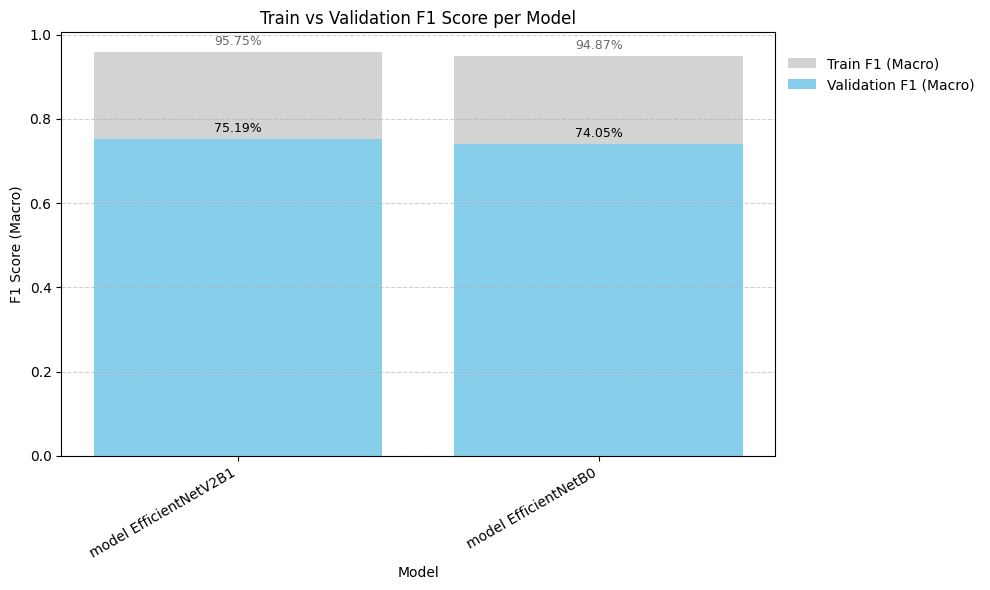

In [59]:
plot_results(train_results, validation_results)

> Best model is EfficientNetV2B1 with combination augmentation and fine-tuning.

# Architecture selection

>Now we will compare different architectures with the some hyperparameters with Keras Tuner:<br>
> - Spatial reduction: max; avg; 
> - Batch normlization after concatenation of image and tabular input 
> - Dropout layer rate [0.0 - 0.5, step 0.1]
> - Add a dense layer between the concatenation and the output layer;
> - Testing different number of neurons in this layer [128 ,256, step 128]
> - Label smoothing for the loss function [0 - 0.15, step 0.05] 
> - Weight decay for the optimizer [1e-4 - 1e-2, log sampled]


In [25]:
def build_model(hp):
    input_shape = (224, 224, 3)
    use_tabular = True  
    freeze_base = True  
    base_model_name = "EfficientNetV2B1"
    optimizer_name = "RMSprop"  
    learning_rate = 1e-3  
    loss_name = "CategoricalCrossentropy"
    n_classes = 202

    spatial_reduction = hp.Choice("spatial_reduction", ["avg", "max"], default="avg")
    dropout_rate = hp.Float("dropout_rate", 0.0, 0.5, step=0.1)  
    use_batch_norm = hp.Boolean("use_batch_norm", default=False)  
    n_dense_extra_layers = hp.Int("n_dense_extra_layers", 0, 1, default=0)
    n_dense_units = hp.Int("n_dense_units", 128, 256, step=128, default=128)
    activation = hp.Choice("activation", ["relu", "leaky_relu"], default="leaky_relu")
    kernel_regularizer_l2 = hp.Float("kernel_l2", 1e-4, 1e-2, sampling="log", default=1e-3)  
    weight_decay = kernel_regularizer_l2  
    label_smoothing = hp.Float("label_smoothing", 0.0, 0.15, step=0.05, default=0.1)


    image_input = keras.Input(shape=input_shape, name="image_input")
    x_img = image_input

    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=input_shape, pooling=None
    )
    base_model.trainable = False

    x_img = base_model(x_img)

    # Spatial Reduction
    if spatial_reduction == "avg":
        x_img = tf.keras.layers.GlobalAveragePooling2D()(x_img)
    else:
        x_img = tf.keras.layers.GlobalMaxPooling2D()(x_img)

    # Tabular input
    tabular_input = keras.Input(shape=(5,), name="tabular_input")
    x = keras.layers.Concatenate()([x_img, tabular_input])

    # Dense head
    if use_batch_norm:
        x = keras.layers.BatchNormalization()(x)

    if dropout_rate > 0:
        x = keras.layers.Dropout(dropout_rate)(x)

    for _ in range(n_dense_extra_layers):
        x = keras.layers.Dense(n_dense_units, kernel_regularizer=keras.regularizers.l2(kernel_regularizer_l2))(x)
        if activation == "relu":
            x = keras.layers.Activation("relu")(x)
        elif activation == "leaky_relu":
            x = keras.layers.LeakyReLU(alpha=0.1)(x)
        x = keras.layers.Dropout(dropout_rate)(x)
        n_dense_units = int(n_dense_units * 0.5)
        dropout_rate *= 0.5

    outputs = keras.layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inputs=[image_input, tabular_input], outputs=outputs)

    # Compile
    OptimizerClass = getattr(tf.keras.optimizers, optimizer_name)
    optimizer = OptimizerClass(learning_rate=learning_rate, weight_decay=weight_decay)

    LossClass = getattr(tf.keras.losses, loss_name)
    loss_fn = LossClass(label_smoothing=label_smoothing)

    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=[
            keras.metrics.F1Score(average="macro", name="f1_macro"),
            keras.metrics.F1Score(average="weighted", name="f1_weighted")
        ]
    )

    return model





In [26]:
tuner = kt.Hyperband(
    build_model,              
    objective=kt.Objective("val_f1_macro", direction="max"),
    max_epochs=70,              
    factor=3,                   
    directory="tuner_results",  
    project_name="rare_species"
)

Reloading Tuner from tuner_results/rare_species/tuner0.json


In [ ]:
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=100,                     
    callbacks=callbacks,         
)


Trial 254 Complete [00h 04m 00s]
val_f1_macro: 0.37747064232826233

Best val_f1_macro So Far: 0.7294774651527405
Total elapsed time: 09h 01m 07s


In [27]:
best_params = tuner.get_best_hyperparameters(num_trials=1)[0]
for param in best_params.values:
    print(f"{param}: {best_params.get(param)}")

spatial_reduction: avg
dropout_rate: 0.1
use_batch_norm: False
n_dense_extra_layers: 0
n_dense_units: 256
activation: leaky_relu
kernel_l2: 0.00020888503603231815
label_smoothing: 0.0
tuner/epochs: 100
tuner/initial_epoch: 34
tuner/bracket: 4
tuner/round: 4
tuner/trial_id: 0143


In [27]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.save("best_model.h5")

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
